In [ ]:
# THỰC HÀNH 5: XÁC ĐỊNH ĐỐI TƯỢNG TRONG ẢNH

## 1. Cài đặt thư viện

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Viết chương trình gán nhãn ảnh

### 2.1 Gán nhãn ảnh

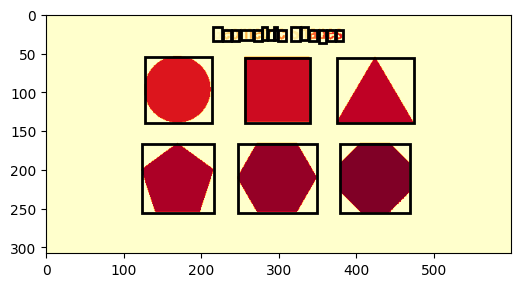

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu
data = Image.open('geometric.png').convert('L')
a = np.asarray(data)
thres = threshold_otsu(a)
b = a > thres 
c = label(b)
c_uint8 = (c % 256).astype(np.uint8)
iio.imwrite('label_output.jpg', c_uint8)
properties = ['Area', 'Centroid', 'BoundingBox']
d = regionprops(c)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
ax.imshow(c, cmap='YlOrRd')
for i in d:
    lr, lc, ur, uc = i['BoundingBox']
    rec_width = uc - lc
    rec_height = ur - lr
    rect = mpatches.Rectangle((lc, lr), rec_width, rec_height, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)

plt.show()


### 2.2 Dò tìm cạnh theo chiều dọc

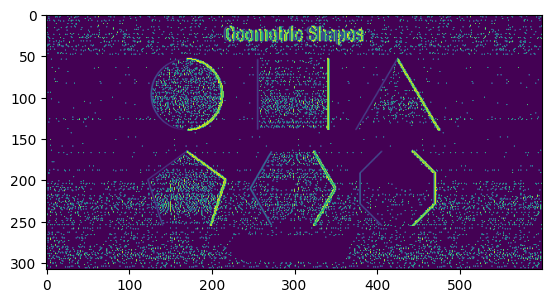

In [8]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png').convert('L')
bmg = abs(data - nd.shift(data, (0, 1), order=0))
plt.imshow(bmg)
plt.show()


### 2.3 Dò tìm cạnh Sobel Filter

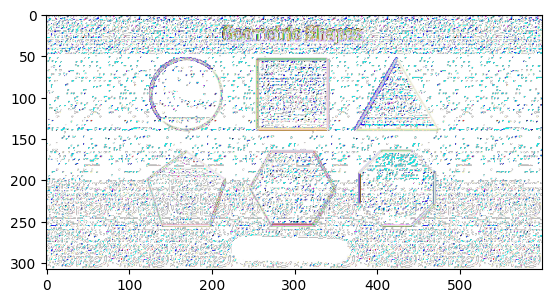

In [9]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png')
a = nd.sobel(data, axis=0)
b = nd.sobel(data, axis=1)
bmg = abs(a) + abs(b)
plt.imshow(bmg)
plt.show()


### 2.4 Xác định góc của đối tượng

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-49.800000000000004..255.0].


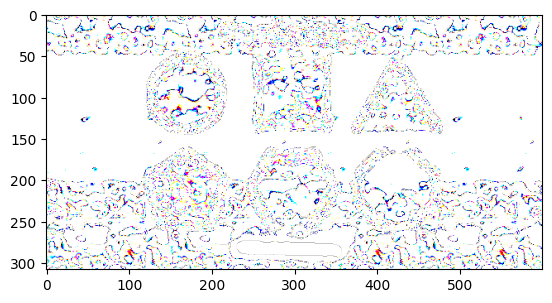

In [3]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def Harris(indata, alpha=0.2):
    x = nd.sobel(indata, 0)
    y = nd.sobel(indata, 1)
    x1 = x ** 2
    y1 = y ** 2
    xy = abs(x * y)
    x1 = nd.gaussian_filter(x1,3)
    y1 = nd.gaussian_filter(y1,3)
    xy = nd.gaussian_filter(xy,3)

    detC = x1 * y1 - 2 * xy
    trC = x1 + y1
    R = detC - alpha * trC**2
    return R

data = Image.open('geometric.png')
bmg = Harris(data)
plt.imshow(bmg)
plt.show()

### 2.5 Dò tìm hình dạng cụ thể trong ảnh với Hough Transform

#### 2.5.1 Dò tìm ảnh thẳng trong ảnh

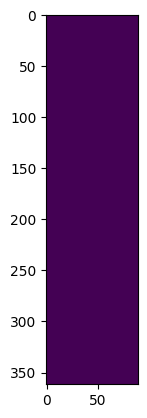

In [11]:
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu


def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float) #Hough space
    w = data + 0
    ok = 1

    theta = np.arange(90)/180 * np.pi
    tp = np.arange(90).astype(float)

    while ok:
        mx = w.max()
        if mx < gamma:
            ok = 0
        else:
            v, h = divmod(w.argmax(), H)
            y = v - V
            x = h - H
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 <= rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v,h] = 0
    return ho


data = np.zeros((256, 256))
data[128, 128] = 1
bmg = LineHough(data, 0.5)
plt.imshow(bmg)
plt.show()

#### 2.5.2 Dò tìm đường tròn trong ảnh

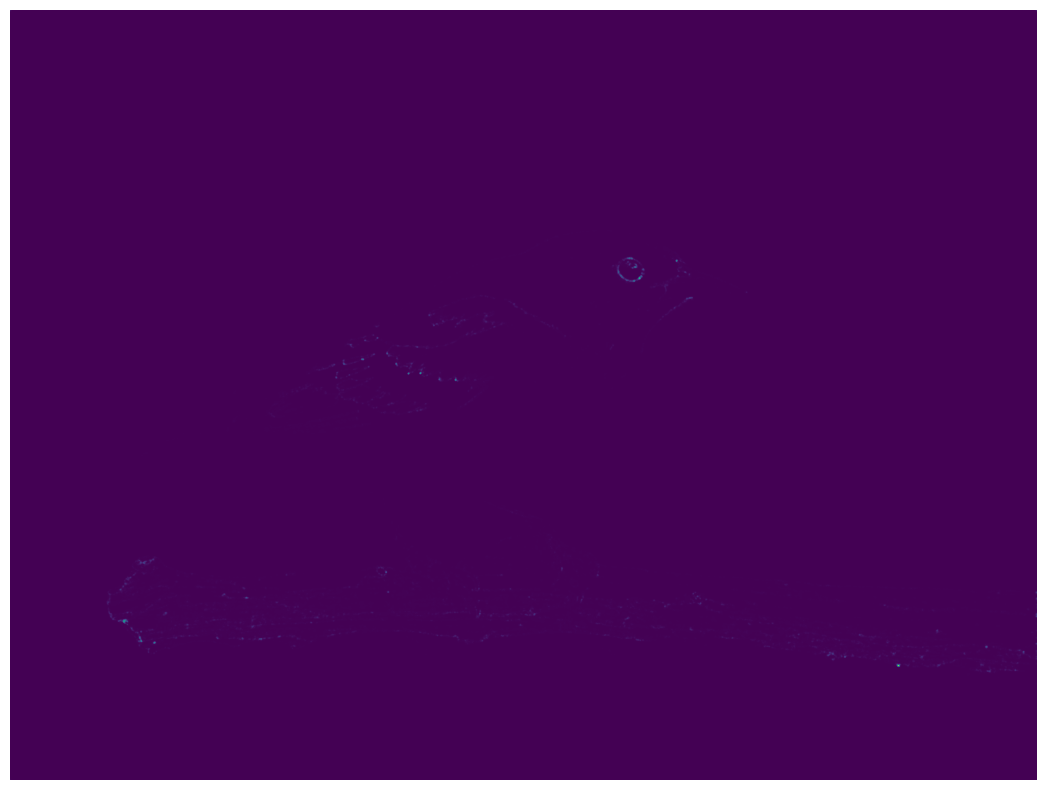

In [12]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.feature import corner_harris
from skimage.color import rgb2gray

data = iio.imread('bird.png')
image_gray = rgb2gray(data)
coordinate = corner_harris(image_gray, k = 0.001)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()

### 2.6 Image matching

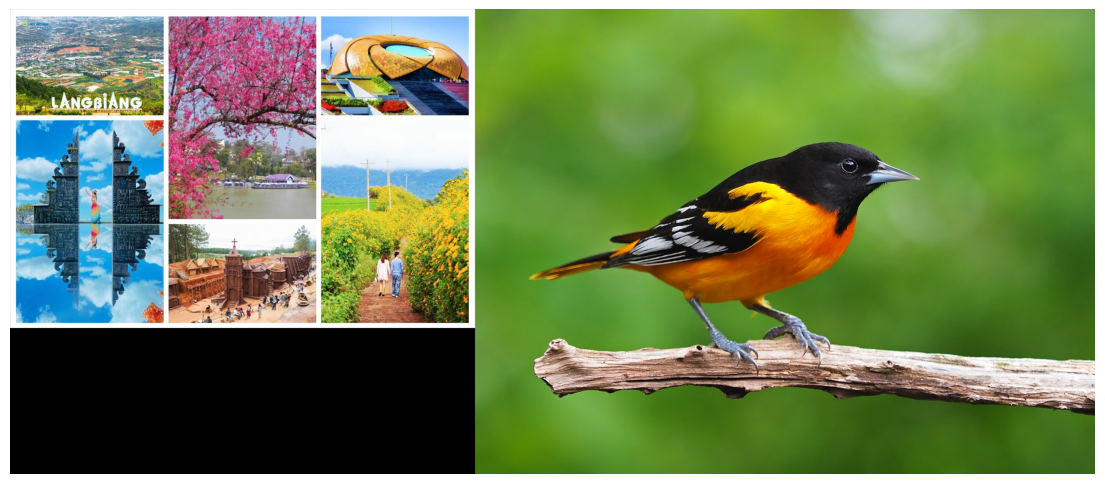

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc hai ảnh
img1 = cv2.imread('exercise/dalat.jpg')
img2 = cv2.imread('bird.png')

# Chuyển ảnh sang grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# === Bước 1: Harris Corner Detector ===
def harris_corners(img, blockSize=2, ksize=3, k=0.04, thresh=0.01):
    dst = cv2.cornerHarris(img, blockSize, ksize, k)
    dst = cv2.dilate(dst, None)
    corners = np.argwhere(dst > thresh * dst.max())
    return corners

corners1 = harris_corners(gray1)
corners2 = harris_corners(gray2)

# === Bước 2: Dùng ORB để mô tả đặc trưng và tìm điểm tương đồng ===
orb = cv2.ORB_create(nfeatures=500)

# KeyPoint từ các điểm Harris (giả sử dùng 100 điểm đầu tiên)
kp1 = [cv2.KeyPoint(float(x[1]), float(x[0]), 20) for x in corners1[:100]]
kp2 = [cv2.KeyPoint(float(x[1]), float(x[0]), 20) for x in corners2[:100]]

# Tính mô tả đặc trưng
kp1, des1 = orb.compute(gray1, kp1)
kp2, des2 = orb.compute(gray2, kp2)

# === Bước 3: So khớp bằng Brute Force Matcher ===
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sắp xếp theo khoảng cách tăng dần
matches = sorted(matches, key=lambda x: x.distance)

# === Bước 4: Hiển thị kết quả ===
matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=2)
plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
